In [10]:
import io
import math
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import geopandas as gpd
from shapely.geometry import box
from tensorflow.keras.models import load_model
from google.colab import drive

In [11]:
drive.mount('/content/drive')

gdf0 = gpd.read_file("/content/drive/My Drive/MAPPA/0")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


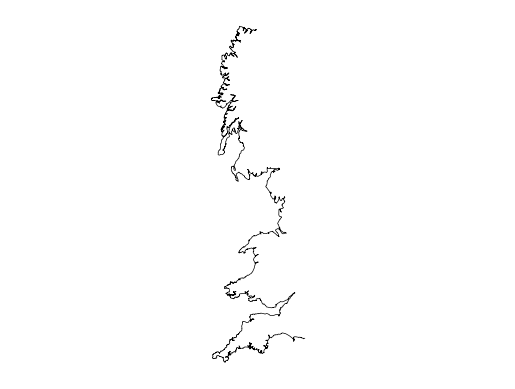

In [39]:
# Upload shapefile downloaded from GADM

gadm = gpd.read_file("/content/drive/My Drive/MAPPA/0/gadm41_GBR_0.shp")

# Explode MultiPolygon
gadm_exploded = gadm.explode(index_parts=False)

# Proietta in CRS metrico (UTM zone 50N, adatto per la Cina orientale)
gadm_proj = gadm_exploded.to_crs(epsg=32650)

# Calculate the area
gadm_proj["area"] = gadm_proj.geometry.area

# Filter out the polygon with lower area, so only the mainland remains

soglia_area = 100e9
gadm_filtered_proj = gadm_proj[gadm_proj["area"] > soglia_area]

gadm_filtered = gadm_filtered_proj.to_crs(epsg=4326)

# Select only a box
bbox = box(-8, 49.8, -2, 59)

# Reproject both the GADM layer and the bounding box into a metric coordinate system.

gadm_proj = gadm_filtered.to_crs("EPSG:32630")
bbox_proj = gpd.GeoSeries([bbox], crs="EPSG:4326").to_crs("EPSG:32630").iloc[0]

clipped = gadm_proj.clip(bbox_proj)
geom = clipped.geometry.iloc[0]

%matplotlib inline

geom = clipped.geometry.iloc[0]

if geom.geom_type == "MultiPolygon":
    geom = list(geom.geoms)[0]

# Remove the straight line

coords = list(geom.exterior.coords)

max_index = max(range(len(coords)), key=lambda i: coords[i][0])

coords = coords[max_index:] + coords[:max_index]

# Select the portion of coastline

start, end = 0, 730000
subset = coords[start:end]

x, y = zip(*subset)

plt.plot(x, y, color="black", linewidth = 0.5)
plt.gca().set_aspect('equal', adjustable='datalim')
plt.axis("equal")
plt.axis('off')

plt.show()

In [40]:
matplotlib.use("Agg")

def rasterize_segments(segments, img_size=(515, 389)):
    '''
    Given the coordinates, it creates a binary image of specific dimensions.
    '''

    fig, ax = plt.subplots(figsize=(img_size[0]/100, img_size[1]/100), dpi=100)
    ax.set_axis_off()
    ax.set_aspect('equal', adjustable='box')

    all_coords = np.vstack(segments)
    min_x, max_x = all_coords[:, 0].min(), all_coords[:, 0].max()
    min_y, max_y = all_coords[:, 1].min(), all_coords[:, 1].max()

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)

    for seg in segments:
        if len(seg) > 1:
            ax.plot(seg[:,0], seg[:,1], color='black', linewidth=1)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    fig.canvas.draw()

    img_rgba = np.array(fig.canvas.renderer.buffer_rgba())
    plt.close(fig)

    img = Image.fromarray(img_rgba).convert("L")
    img = img.resize(img_size, Image.LANCZOS)
    img = img.point(lambda p: 255 if p > 128 else 0)

    return np.array(img)

In [41]:
def Image_Loader_fractal(dataframe, range_0, range_length):
   '''
   This function gives as output the set of images that will be evaluated and their respective fractal dimension (label) as np arrays.
   It is specific for the box counting.
   '''
   eval_set = []

   for i in range(range_0,range_length):

      coords = dataframe[i]

      threshold = 200

      img = rasterize_segments([coords], img_size=(515, 389))

      img1 = np.array(img)
      image = (img1 > threshold).astype(np.float32)
      eval_set.append(image)

   eval_set = np.asarray(eval_set)
   return eval_set

In [42]:
def Image_Loader(dataframe, range_0, range_length):
   '''
   This function gives as output the set of images that will be evaluated and their respective fractal dimension (label) as np arrays
   '''

   eval_set = []

   for i in range(range_0,range_length):

      coords = dataframe[i]

      threshold = 200

      img = rasterize_segments([coords], img_size=(515, 389))

      img1 = np.array(img)
      img2 = (img1 > threshold).astype(np.float32)

      image = img2[:, :, np.newaxis]
      eval_set.append(image)

   eval_set = np.asarray(eval_set)
   return eval_set

In [43]:
def boxcount(Z, k):
    '''
    Given the dimension of the box k, and the matrix Z, it returns the number of
    boxes, used to cover the matrix, with at least a 1 inside.
    '''
    rows, cols = Z.shape
    n_rows = rows // k
    n_cols = cols // k

    count = 0
    for i in range(n_rows):
        for j in range(n_cols):
            block = Z[i*k:(i+1)*k, j*k:(j+1)*k]
            if np.any(block):
                count += 1
    return count

def fractal_dimension(image):
    """
    Given an image, it converts it into a binary matrix with values 0 and 1.
    Using this binary representation, it applies the box‑counting method:
    for multiple grid sizes, it counts how many boxes contain part of the curve.

    The fractal dimension is estimated as the slope of the linear regression
    between log(box count) and log(box size).
    """

    img = np.array(image)

    binary = (img == 0).astype(np.uint8)

    sizes = [2, 4, 8, 16, 32, 64]
    counts = [boxcount(binary, k) for k in sizes]

    log_sizes = np.log(sizes)
    log_counts = np.log(counts)

    coeffs = np.polyfit(log_sizes, log_counts, 1)
    fractal_dim = -coeffs[0]

    fit_line = coeffs[0] * log_sizes + coeffs[1]

    return fractal_dim

Divide the coastline in 73 portions of 10.000 points.

In [44]:
test = np.array(subset)

test_df = []

N = 73
n = 10000


for i in range(N):

    start = i*n

    end = start + n

    valore = test[start:end]
    test_df.append(valore)

In [45]:
ms = '/content/drive/My Drive/Modelli/Coordinate2/AlexNet_model.keras'
model = load_model(ms)

In [46]:
# evaluate the value with the CNN

test_image_set= Image_Loader(test_df, 0, len(test_df))

Basins_Characterized_df = model.predict(test_image_set)

predicted_values = Basins_Characterized_df.flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 8s/step


In [47]:
# evaluate the values with the box counting

D = []
test_image_set= Image_Loader_fractal(test_df, 0, len(test_df))
for i in test_image_set:
  dimfrattale = fractal_dimension(i)
  D.append(dimfrattale)

In [48]:
# Put everything togheter in a dataframe

D = np.array(D)

result_df = pd.DataFrame({
    'CNN': predicted_values,
    'Box' : D
})
print(result_df[['CNN', 'Box']])

         CNN       Box
0   1.052920  1.061678
1   1.130388  1.147567
2   1.198315  1.197159
3   1.294213  1.216727
4   1.259207  1.162525
..       ...       ...
68  1.218248  1.200949
69  1.325876  1.268132
70  1.219424  1.266714
71  1.182279  1.210012
72  1.186911  1.196404

[73 rows x 2 columns]


Divide the coastline in 13 portions of 56.153 points.

In [49]:
test2 = np.array(subset)

test_df2 = []

N2 = 13
n2 = 56153


for i in range(N2):

    start = i*n2

    end = start + n2

    valore = test2[start:end]
    test_df2.append(valore)

In [50]:
# evaluate the value with the CNN

test_image_set2= Image_Loader(test_df2, 0, len(test_df2))

Basins_Characterized_df2 = model.predict(test_image_set2)

predicted_values2 = Basins_Characterized_df2.flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [51]:
# evaluate the values with the box counting

D2 = []
test_image_set2= Image_Loader_fractal(test_df2, 0, len(test_df2))
for i in test_image_set2:
  dimfrattale = fractal_dimension(i)
  D2.append(dimfrattale)

In [52]:
# Put everything togheter in a dataframe

D2 = np.array(D2)

result_df2 = pd.DataFrame({
    'CNN': predicted_values2,
    'Box' : D2
})
print(result_df2[['CNN', 'Box']])

         CNN       Box
0   1.198965  1.167410
1   1.243064  1.201249
2   1.136739  1.120948
3   1.204105  1.210170
4   1.144202  1.136947
5   1.101178  1.169093
6   1.228676  1.164115
7   1.144286  1.149985
8   1.322117  1.237391
9   1.351525  1.259279
10  1.356384  1.233022
11  1.306857  1.287239
12  1.306336  1.245669


In [53]:
# Select the extreme for the color scale

vmin1=min(result_df['CNN'].min(), result_df2['CNN'].min())
vmax1=max(result_df['CNN'].max(), result_df2['CNN'].max())
vmin2=min(result_df['Box'].min(), result_df2['Box'].min())
vmax2=max(result_df['Box'].max(), result_df2['Box'].max())

Represent the coastline with a color scale based on the fractal dimension.

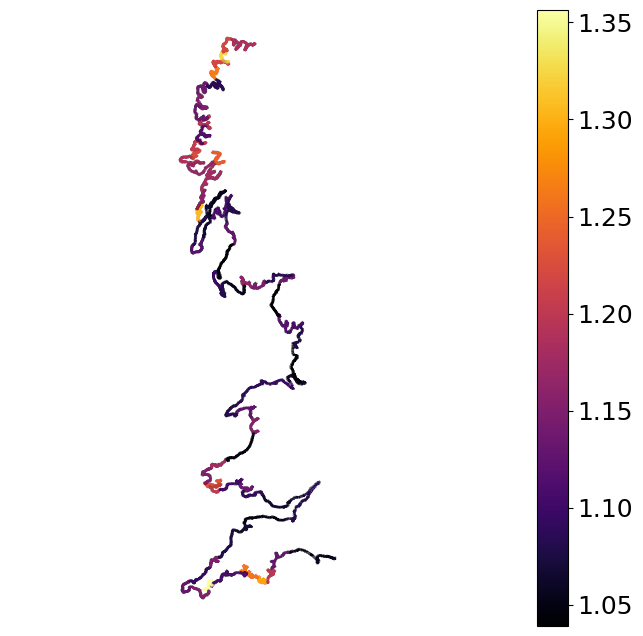

In [54]:
%matplotlib inline

N = 73
n = 10000

fig, ax = plt.subplots(figsize=(8,8))

norm = plt.Normalize(vmin=np.min([vmin1, vmin2]), vmax=np.max([vmax1, vmax2]))
cmap = plt.cm.inferno

for i in range(N):
    start = i*n
    end = start + n

    r, t = x[start:end], y[start:end]

    c = result_df['CNN'].iloc[i]

    points = np.array([r, t]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array(np.full(len(segments), c))

    ax.add_collection(lc)

ax.autoscale()
ax.axis("off")
ax.set_aspect('equal', adjustable='datalim')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=18)
sm.set_array([])

plt.show()

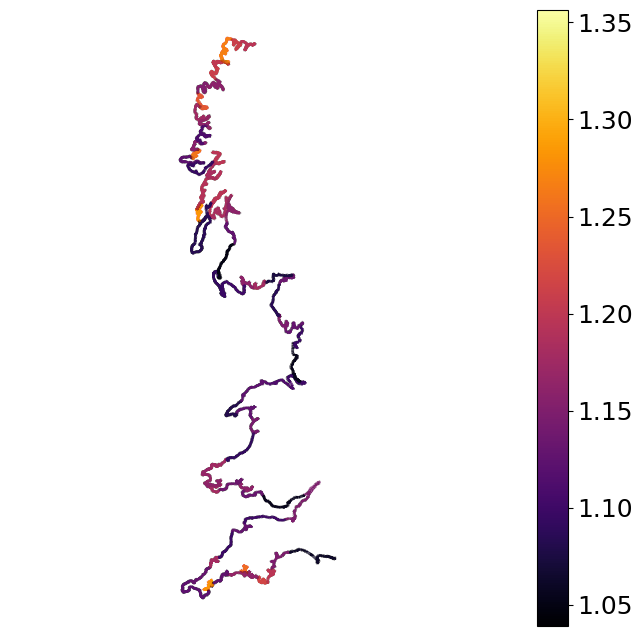

In [55]:
%matplotlib inline

N = 73
n = 10000

fig, ax = plt.subplots(figsize=(8,8))

norm = plt.Normalize(vmin=np.min([vmin1, vmin2]), vmax=np.max([vmax1, vmax2]))
cmap = plt.cm.inferno

for i in range(N):
    start = i*n
    end = start + n

    r, t = x[start:end], y[start:end]

    c = result_df['Box'].iloc[i]

    points = np.array([r, t]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array(np.full(len(segments), c))

    ax.add_collection(lc)

ax.autoscale()
ax.axis("off")
ax.set_aspect('equal', adjustable='datalim')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=18)

plt.show()

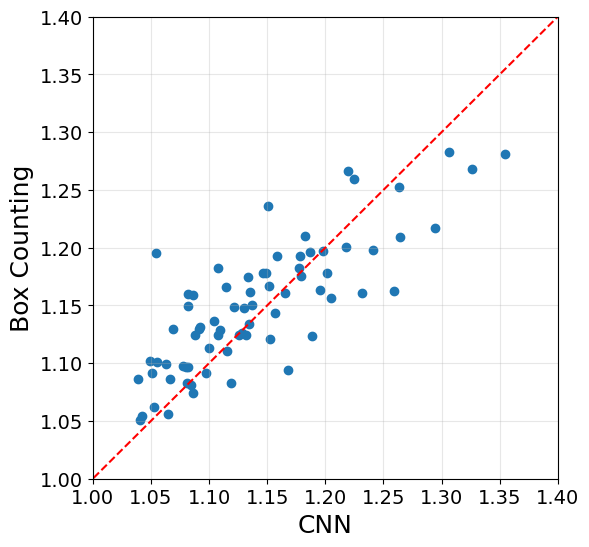

In [57]:
plt.figure(figsize=(6, 6))
plt.scatter(result_df['CNN'], result_df['Box'])
plt.xlabel('CNN', fontsize=18)
plt.ylabel('Box Counting', fontsize=18)
plt.xlim(1, 1.4)
plt.ylim(1, 1.4)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.plot([0.9, 1.5], [0.9, 1.5], 'r--')
plt.grid(True, alpha=0.3)

plt.show()

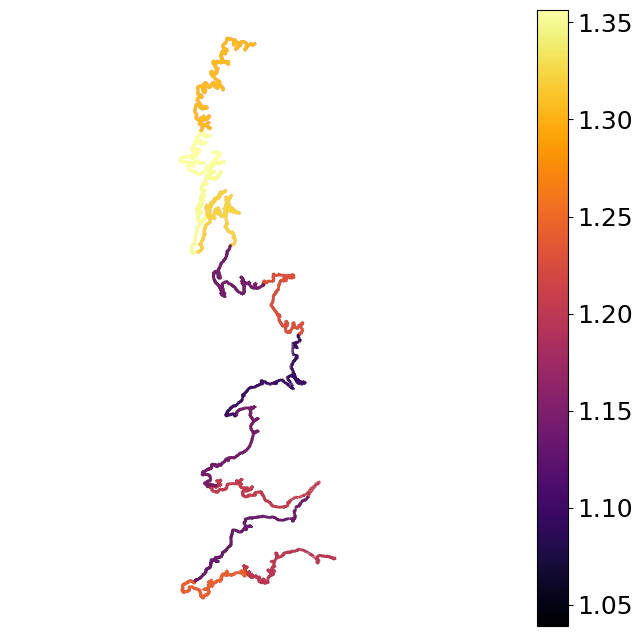

In [58]:
%matplotlib inline

N2 = 13
n2 = 56153

fig, ax = plt.subplots(figsize=(8,8))

norm = plt.Normalize(vmin=np.min([vmin1, vmin2]), vmax=np.max([vmax1, vmax2]))
cmap = plt.cm.inferno

for i in range(N2):
    start = i*n2
    end = start + n2

    r, t = x[start:end], y[start:end]

    c = result_df2['CNN'].iloc[i]

    points = np.array([r, t]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array(np.full(len(segments), c))

    ax.add_collection(lc)

ax.autoscale()
ax.axis("off")
ax.set_aspect('equal', adjustable='datalim')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=18)
sm.set_array([])

plt.show()

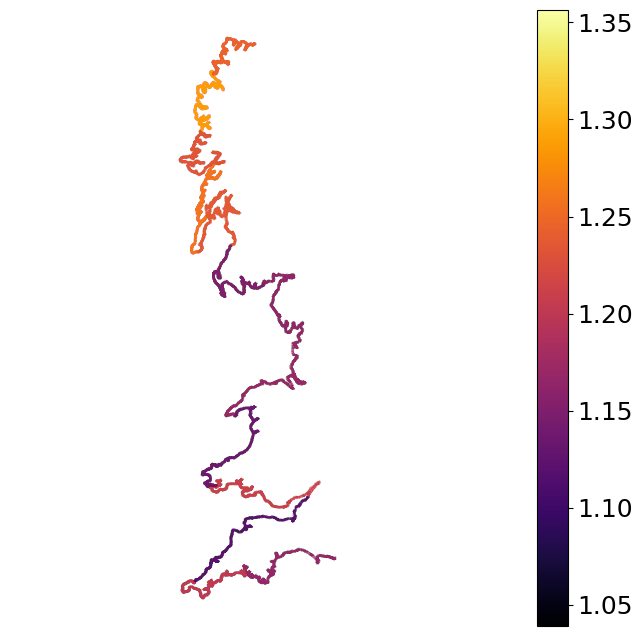

In [59]:
%matplotlib inline

N2 = 13
n2 = 56153

fig, ax = plt.subplots(figsize=(8,8))

norm = plt.Normalize(vmin=np.min([vmin1, vmin2]), vmax=np.max([vmax1, vmax2]))
cmap = plt.cm.inferno

for i in range(N2):
    start = i*n2
    end = start + n2

    r, t = x[start:end], y[start:end]

    c = result_df2['Box'].iloc[i]

    points = np.array([r, t]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array(np.full(len(segments), c))

    ax.add_collection(lc)

ax.autoscale()
ax.axis("off")
ax.set_aspect('equal', adjustable='datalim')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=18)

plt.show()

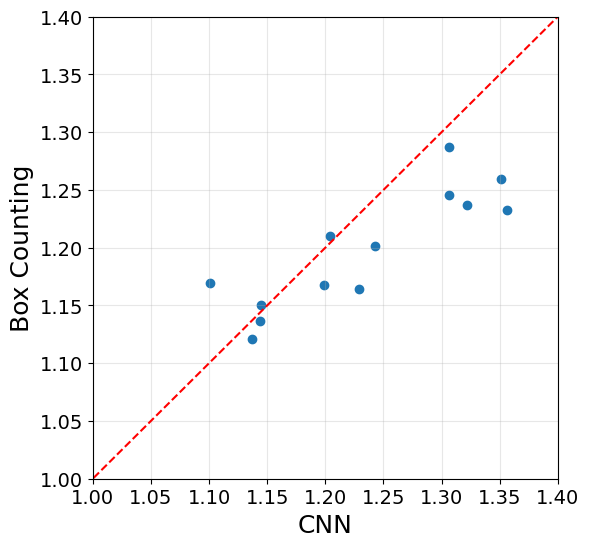

In [60]:
plt.figure(figsize=(6, 6))
plt.scatter(result_df2['CNN'], result_df2['Box'])
plt.xlabel('CNN', fontsize=18)
plt.ylabel('Box Counting', fontsize=18)
plt.xlim(1, 1.4)
plt.ylim(1, 1.4)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.plot([0.9, 1.5], [0.9, 1.5], 'r--')
plt.grid(True, alpha=0.3)

plt.show()